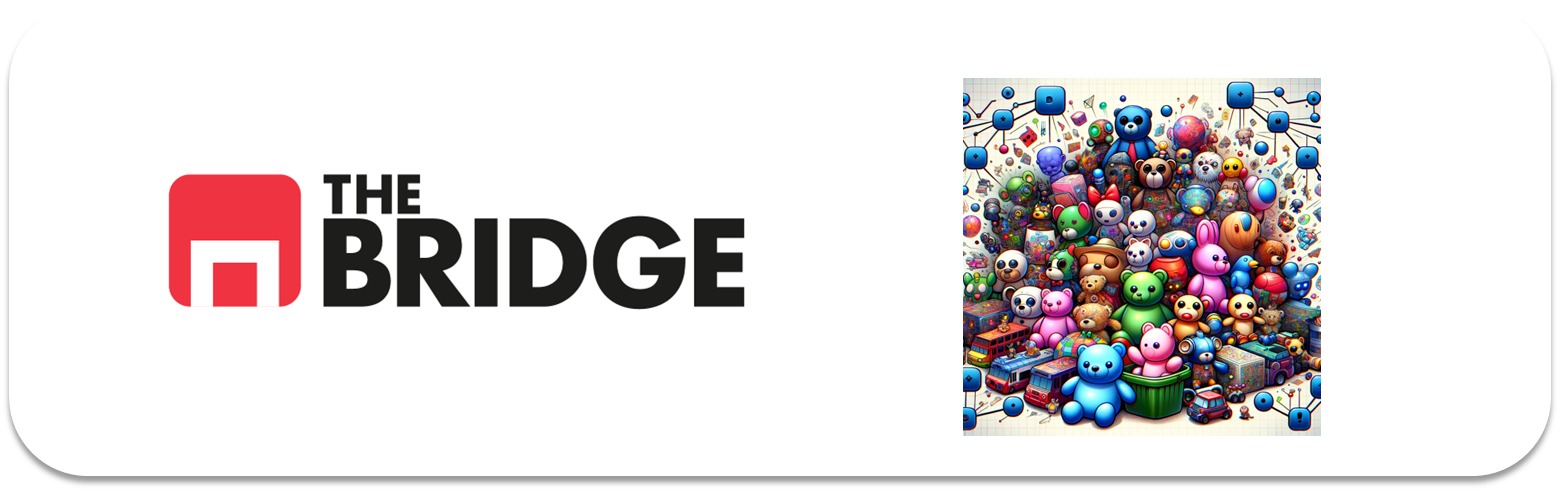

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [4]:
df = pd.read_csv("./data/empowering_drinks.csv", sep = "|")
df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [6]:
df.shape

(153, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [8]:
df.isna().sum()

Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Azúcares,153.0,0.019231,1.026182,-2.434235,-0.816038,0.061000,0.876275,2.259772
Vitamínas del grupo B,153.0,0.037273,0.995984,-3.679162,-0.499016,-0.023821,0.707247,3.156325
Cafeína,153.0,0.041057,1.040928,-1.695971,-1.043392,0.211566,0.894264,3.062832
Ácido Cítrico,153.0,0.080022,1.009450,-1.493188,-0.738463,-0.165254,0.917474,2.971473
Taurina,153.0,-0.044088,0.934399,-1.634288,-0.799428,-0.154899,0.493956,2.431870


In [11]:
num_cols = df.select_dtypes(include="number").columns.to_list()
num_cols

['Azúcares', 'Vitamínas del grupo B', 'Cafeína', 'Ácido Cítrico', 'Taurina']

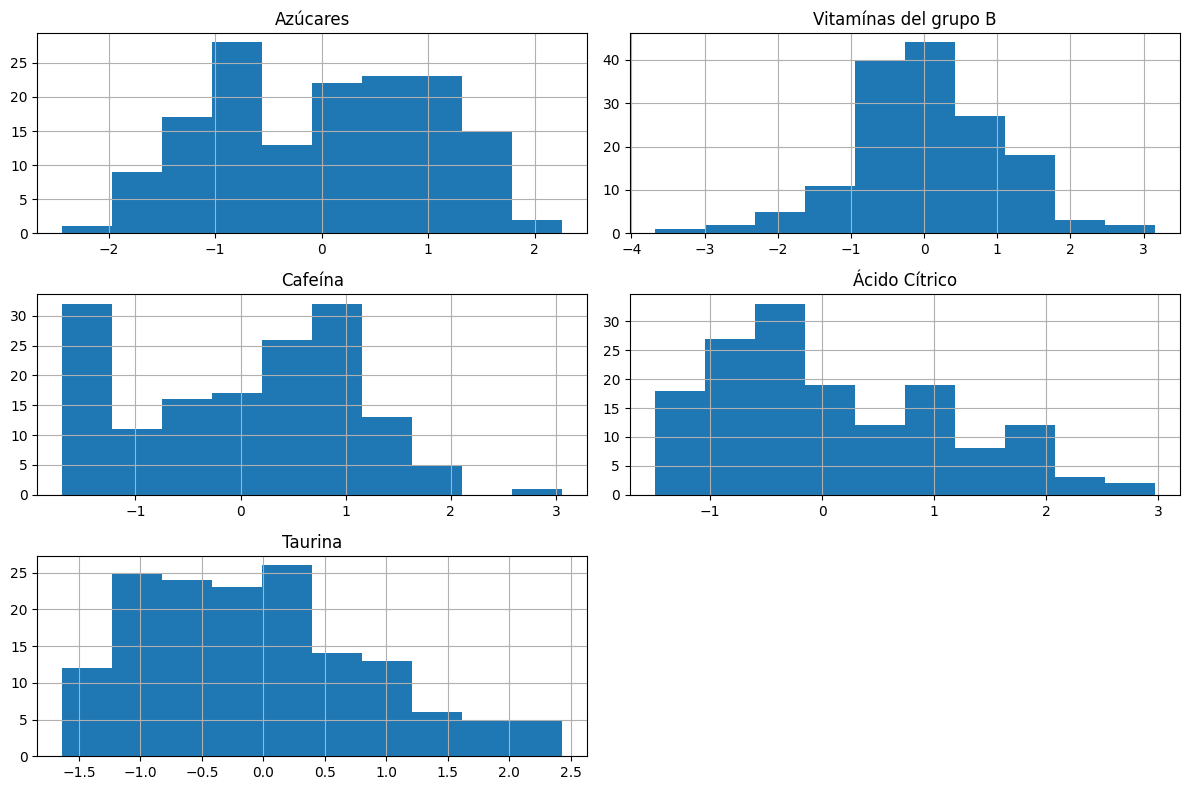

In [14]:
df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show();

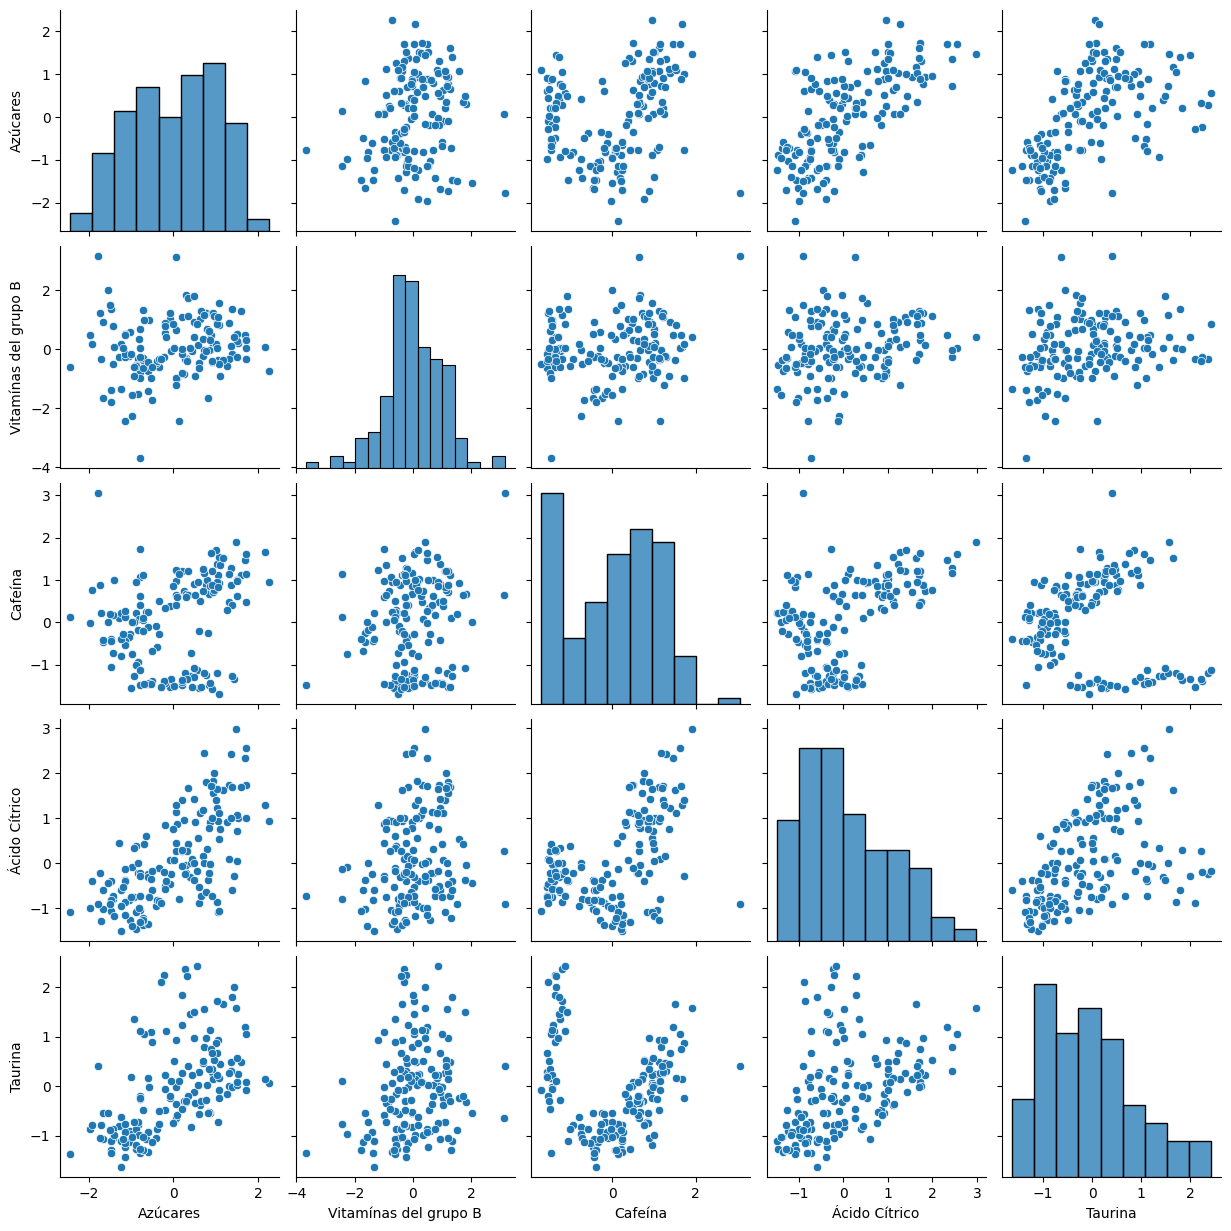

In [16]:
sns.pairplot(df[num_cols])
plt.show();

In [ ]:
# Tenemos datos que no muestran blobs claros, por lo que DBSCAN puediera ser una buena opción para encontrar grupos de datos. Sin embargo, es importante destacar que DBSCAN es sensible a la elección de los parámetros `eps` (distancia máxima entre dos puntos para que se consideren vecinos) y `min_samples` (número mínimo de puntos necesarios para formar un cluster). Por lo tanto, es recomendable realizar una exploración cuidadosa de estos parámetros para obtener resultados óptimos.
# Puede que los datos sean ruidosos, lo que podría afectar la capacidad de DBSCAN para identificar clusters significativos. En este caso, es posible que sea necesario realizar un preprocesamiento adicional, como la eliminación de outliers o la normalización de los datos, antes de aplicar DBSCAN.
# Puede que se trate de multicolinealidad entre las variables numéricas, lo que podría dificultar la identificación de clusters significativos. En este caso, es posible que sea necesario realizar una reducción de dimensionalidad, como PCA, antes de aplicar DBSCAN.

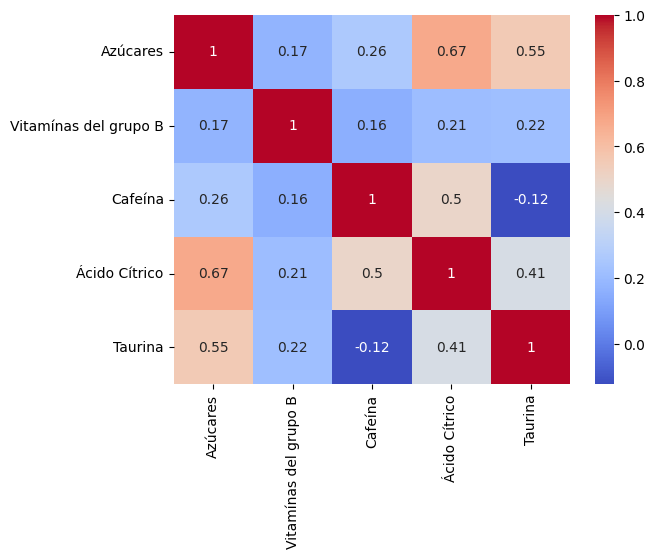

In [18]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm");

B. Modelado:
1. KMeans

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[num_cols])
X_scaled[:5]

array([[ 1.46592517,  0.19620686,  0.9578236 ,  0.92728869,  0.31761153],
       [ 0.22199249, -0.87161212,  0.66752574,  0.87981304, -0.26760757],
       [ 0.17368442,  1.07991912,  1.13200232,  1.30709389,  0.33618991],
       [ 1.6350034 ,  0.45395627,  1.37391721,  2.24078167,  1.32084426],
       [ 0.27030055,  1.816346  ,  0.59978957, -0.1171756 , -0.29547515]])

In [33]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)

labels_k3 =km.fit_predict(X_scaled)

In [34]:
from sklearn.metrics import silhouette_score

sil_k3 = silhouette_score(X_scaled, km.labels_)
sil_k3

0.3978205860790234

In [35]:
km4 = KMeans(n_clusters=4, random_state=42)
labels_k4 = km4.fit_predict(X_scaled)

sil_k4 = silhouette_score(X_scaled, km4.labels_)
sil_k4

0.35635171742398253

In [36]:
km5 = KMeans(n_clusters=5, random_state=42)
labels_k5 = km5.fit_predict(X_scaled)

sil_k5 = silhouette_score(X_scaled, km5.labels_)
sil_k5

print(f"Silhouette Score con 3 clusters: {sil_k3:.2f}")
print(f"Silhouette Score con 4 clusters: {sil_k4:.2f}")
print(f"Silhouette Score con 5 clusters: {sil_k5:.2f}")

Silhouette Score con 3 clusters: 0.40
Silhouette Score con 4 clusters: 0.36
Silhouette Score con 5 clusters: 0.32


In [37]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    km_inertia = KMeans(n_clusters=k, random_state=42)
    km_inertia.fit(X_scaled)
    inertia.append(km_inertia.inertia_)

In [ ]:
# Hemos utilizado 3 y 4 clusters para evaluar el rendimiento de KMeans
# Hemos obtenido mejores resultado del Silhouette Score con 3 clusters
# Cuando subimos a 4, el sil-score baja a 0.35, lo que sugiere que los clusters no están tan bien definidos como con 3 clusters. 
# Esto podría indicar que 3 clusters es una mejor opción para este conjunto de datos en particular. 
# Sin embargo, es importante tener en cuenta que el Silhouette Score es solo una métrica y no debe ser la única consideración al elegir el número de clusters. 
# Es recomendable también considerar otros factores, como la interpretabilidad de los clusters y el contexto del problema.

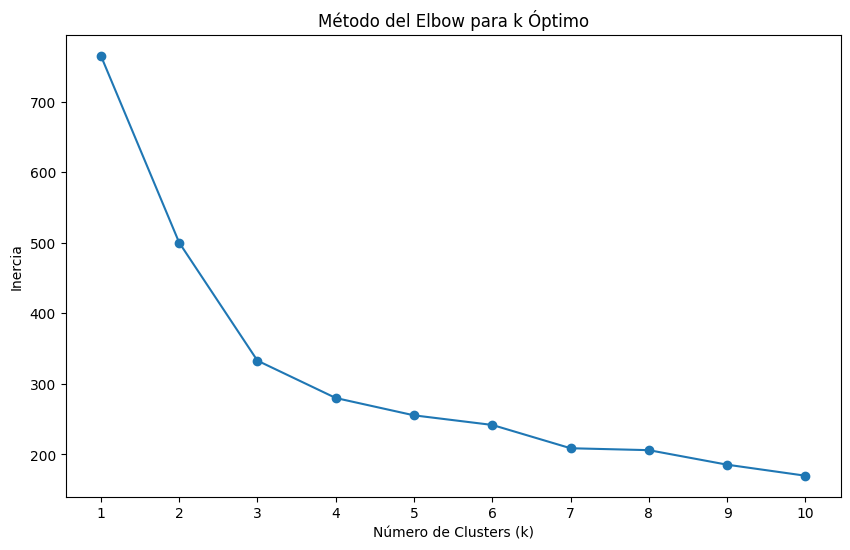

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker = "o")
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Elbow para k Óptimo')
plt.xticks(k_values)
plt.show();

In [39]:
pd.Series(labels_k3).value_counts()

2    58
0    58
1    37
Name: count, dtype: int64

In [ ]:
# Tenemos resultados muy coherentes al utilizar KMeans con 3 clusters
# Todo apunta, desde mi percepción inicial al mirar los plots hasta los resultados del Silhouette Score y el método elbow
# que hay una buena separación entre los clusters al utilizar 3 clusters.
# Con esto tendríamos 3 buenas recetas de bebidas energéticas, cada una con características distintas.

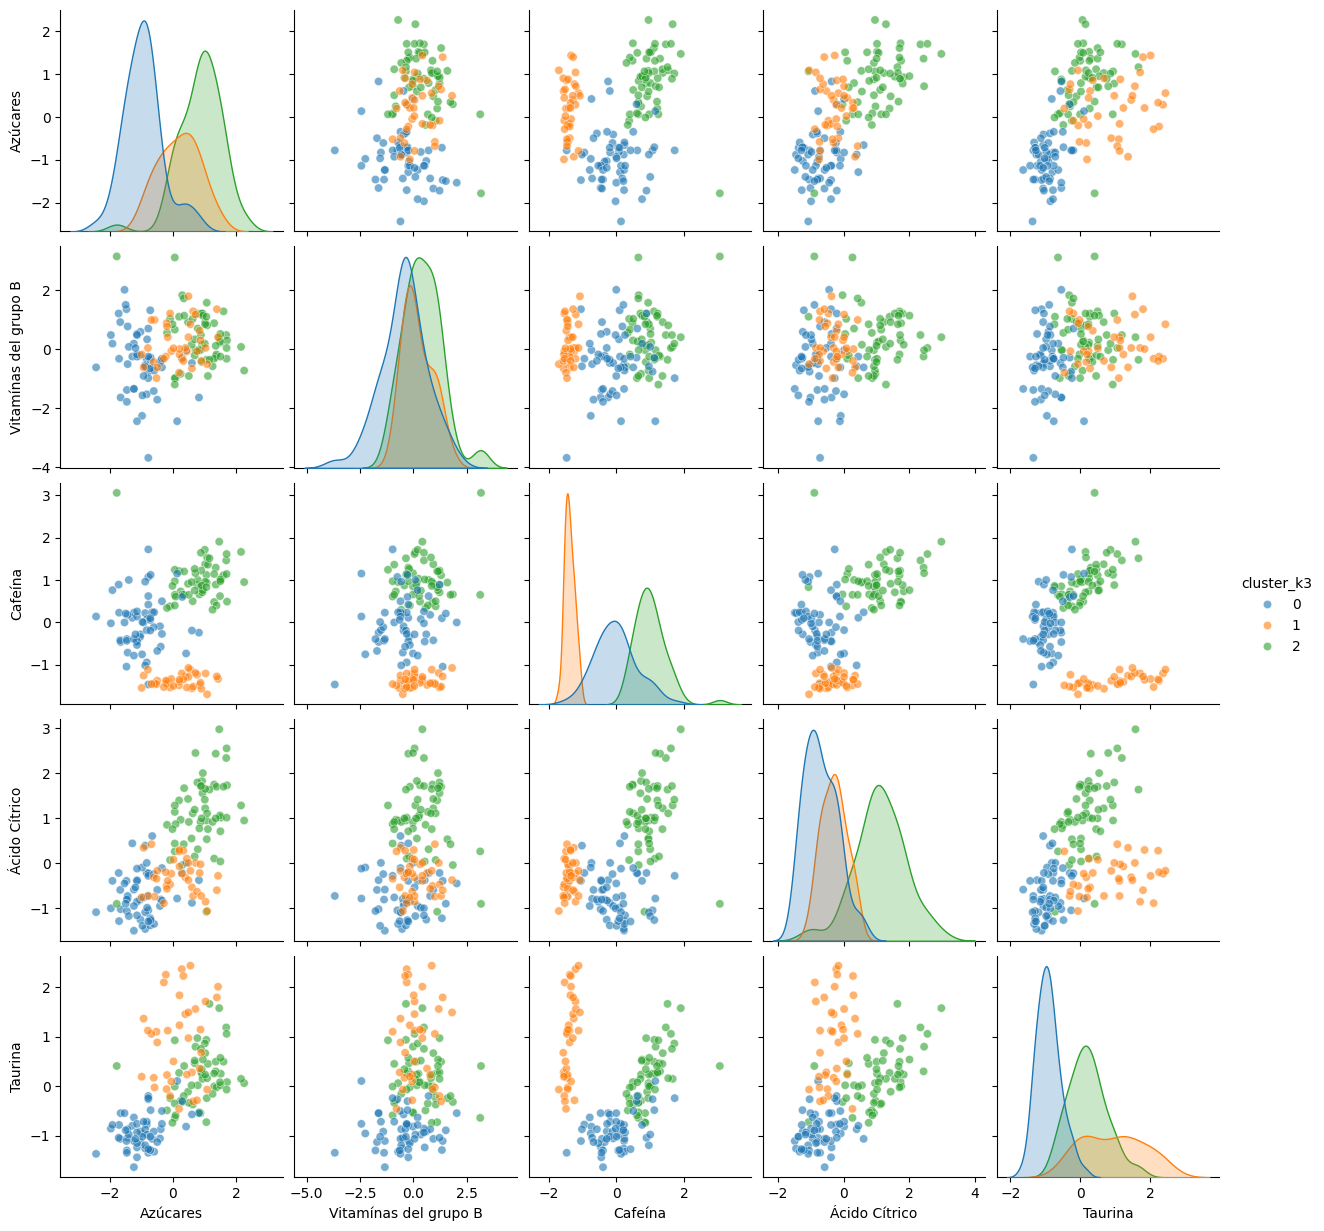

In [40]:
df["cluster_k3"] = labels_k3
sns.pairplot(df, hue="cluster_k3", palette="tab10", plot_kws={"alpha":0.6})

In [41]:
df["cluster_k3"] = labels_k3
df["cluster_k4"] = labels_k4
df["cluster_k5"] = labels_k5

In [43]:
print("Value Counts de cada cluster:")
print(df["cluster_k3"].value_counts())
print(df["cluster_k4"].value_counts())
print(df["cluster_k5"].value_counts())

Value Counts de cada cluster:
cluster_k3
2    58
0    58
1    37
Name: count, dtype: int64
cluster_k4
2    50
3    43
1    37
0    23
Name: count, dtype: int64
cluster_k5
2    53
3    41
4    23
0    21
1    15
Name: count, dtype: int64


In [45]:
print(df.groupby("cluster_k3").mean())
print(df.groupby("cluster_k4").mean())
print(df.groupby("cluster_k5").mean())

            Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico  \
cluster_k3                                                             
0          -0.947445              -0.441034 -0.018308      -0.699755   
1           0.193422               0.190284 -1.382700      -0.302761   
2           0.874784               0.417971  1.008681       1.103987   

             Taurina  cluster_k4  cluster_k5  
cluster_k3                                    
0          -0.912493    2.224138    2.189655  
1           0.933003    1.000000    2.783784  
2           0.201002    1.724138    1.827586  
            Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico  \
cluster_k4                                                             
0          -0.891765               1.129995  0.407122      -0.462242   
1           0.193422               0.190284 -1.382700      -0.302761   
2           1.020801               0.216700  1.020964       1.273309   
3          -0.807995              -0.887502 

In [ ]:
# Hay distinción clara entre clusters y recetas para las bebidas con 3 clusters
# Lo probaremos con DBSCAN

2. DBSCAN:

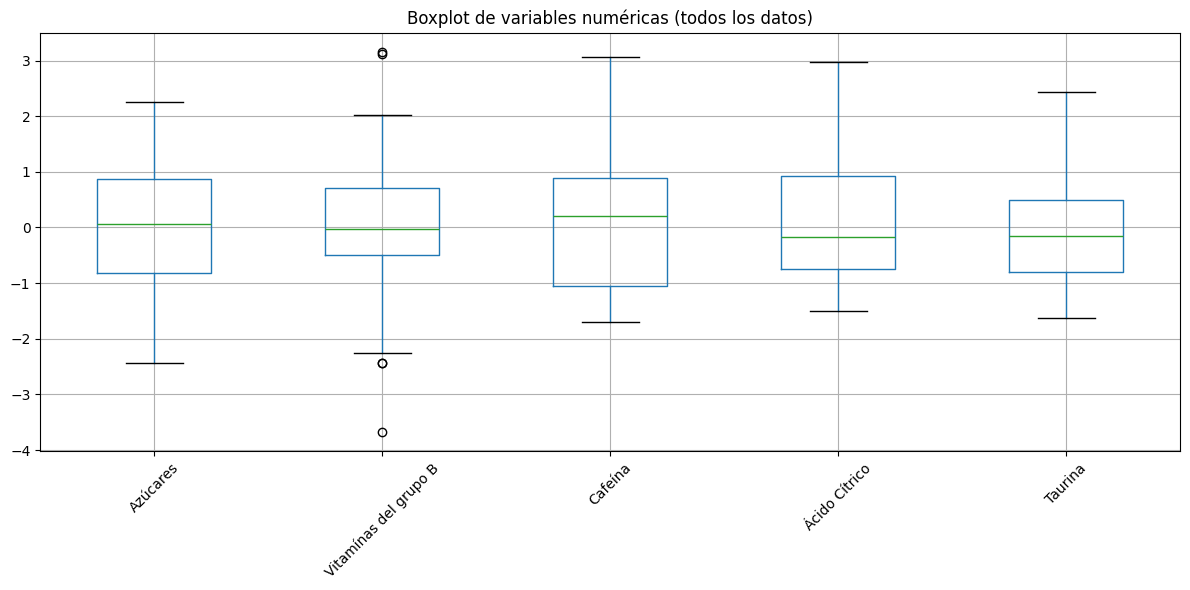

In [46]:
plt.figure(figsize=(12,6))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot de variables numéricas (todos los datos)")
plt.tight_layout()
plt.show();

In [ ]:
# Lo boxplots no muestran muchos outliers, por lo que puede que DBSCAN no tenga una gran ventaja en este caso.

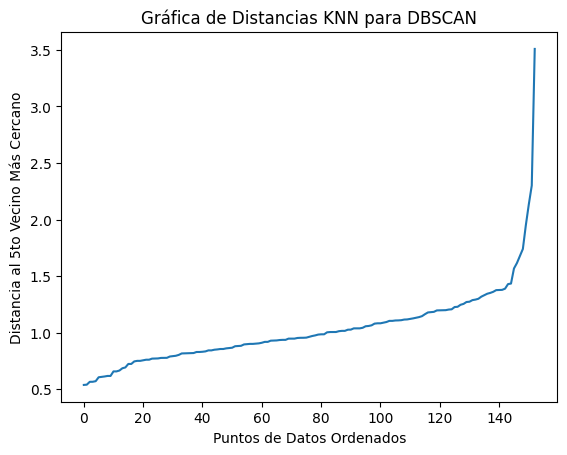

In [47]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=5)
knn_fit = knn.fit(X_scaled)
distances,indices = knn_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])
plt.plot(distances)
plt.title("Gráfica de Distancias KNN para DBSCAN")
plt.xlabel("Puntos de Datos Ordenados")
plt.ylabel("Distancia al 5to Vecino Más Cercano")
plt.show();

In [48]:
from sklearn.cluster import DBSCAN

db_14 = DBSCAN(eps=1.4, min_samples=5)
labels_14 = db_14.fit_predict(X_scaled)

np.unique(labels_14, return_counts=True)

(array([-1,  0]), array([  4, 149]))

In [49]:
db_15 = DBSCAN(eps=1.5, min_samples=5)
labels_15 = db_15.fit_predict(X_scaled)

np.unique(labels_15, return_counts=True)

(array([-1,  0]), array([  4, 149]))

In [ ]:
# Hemos utilizado KNN para determinar un valor adecuado para eps.
# Al probar 1.4 y 1.5 vemos que obtenemos el mismo resultado con ambos: 1 cluster de 149 puntos con unos pocos outliers
# Por lo que DBSCAN no parece ser la mejor opción para este dataset ya que los datos no están significativamente separados por densidad

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [51]:
df2 = pd.read_csv("./data/new_experiments.csv", sep = "|")
df2.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [52]:
num_cols2 = df2.select_dtypes(include="number").columns.to_list()
num_cols2

['Azúcares', 'Vitamínas del grupo B', 'Cafeína', 'Ácido Cítrico', 'Taurina']

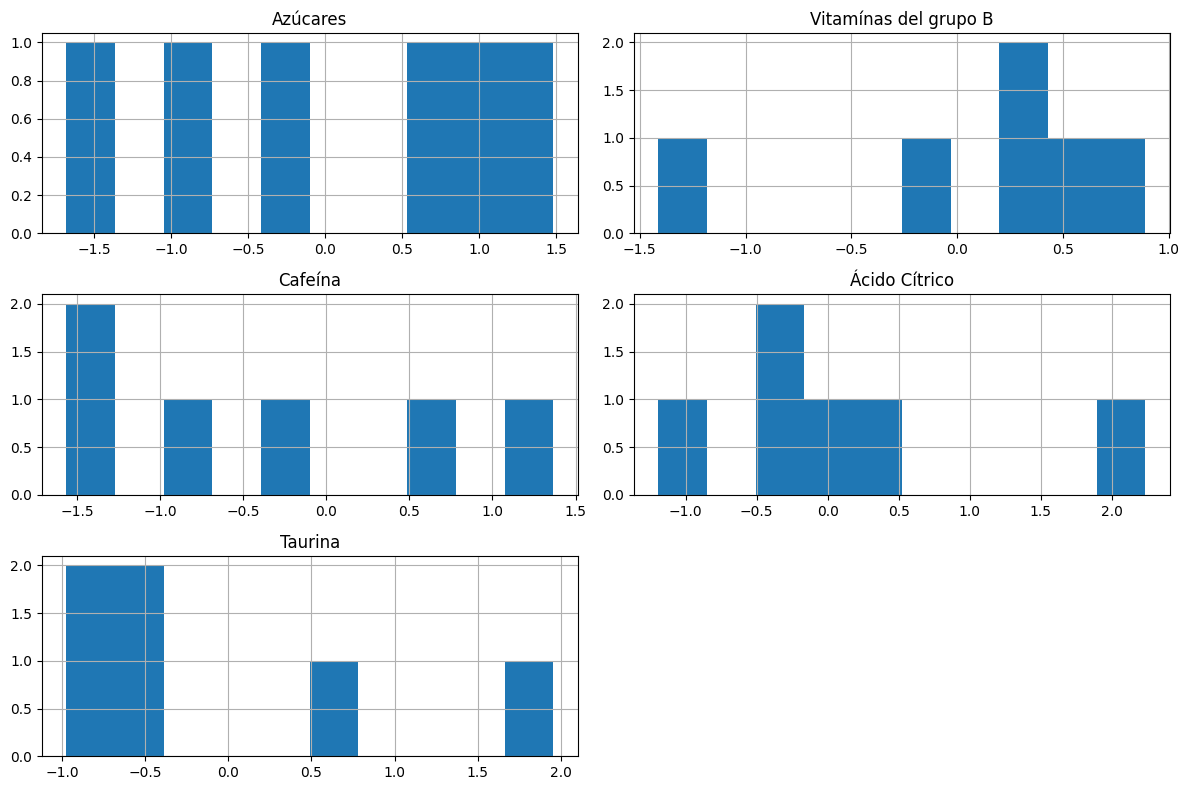

In [53]:
df2[num_cols2].hist(figsize=(12,8))
plt.tight_layout()
plt.show();

In [54]:
for col in df2.columns:
    print(col, sorted(df2[col].unique()))

Azúcares [np.float64(-1.6807237184214292), np.float64(-0.9272120897571632), np.float64(-0.2848743079450018), np.float64(0.6168691165220721), np.float64(0.96274330672862), np.float64(1.481554592038443)]
Vitamínas del grupo B [np.float64(-1.4128508690653407), np.float64(-0.2431417774670599), np.float64(0.3051593592196358), np.float64(0.3417127683320813), np.float64(0.6341400412316519), np.float64(0.8900139050187754)]
Cafeína [np.float64(-1.56545485272353), np.float64(-1.3546218410326432), np.float64(-0.7823608093002373), np.float64(-0.3406154514717134), np.float64(0.5830339330788366), np.float64(1.3661279765021292)]
Ácido Cítrico [np.float64(-1.1938452341062846), np.float64(-0.4200132556250206), np.float64(-0.2130211626156289), np.float64(-0.0856414130713879), np.float64(0.3124203042543651), np.float64(2.2390390161110103)]
Taurina [np.float64(-0.9767819017927332), np.float64(-0.7172399120156373), np.float64(-0.6653315140602182), np.float64(-0.5225834196828154), np.float64(0.7318695309064

In [ ]:
# En este caso, tenemos un dataset con datos casi ordinales, separaciones definidas. Parecen estar escalados con un StandardScaler

In [60]:
scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(df2[num_cols2])
X_scaled2[:5]

array([[ 1.3210508 ,  0.29070095,  1.64918715,  2.01848902,  0.73199114],
       [ 0.53515655,  1.06590348,  0.89619243,  0.19491631, -0.60630964],
       [-1.55307671,  0.33915111,  0.00804482, -0.3024217 , -0.90463055],
       [-0.28441887, -1.98645649, -0.41672144, -1.23078599, -0.65602979],
       [-0.86822602,  0.72675237, -1.16971616, -0.18185491, -0.46957922]])

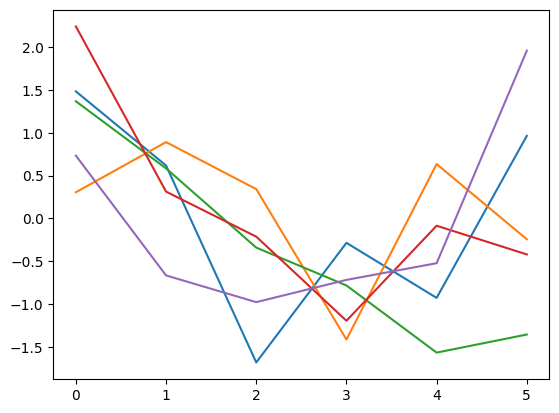

In [69]:
plt.plot(df2[num_cols2])
plt.show();

In [63]:
X_scaled2.shape
k_values

range(2, 7)

In [64]:
n = X_scaled2.shape[0]
k_values = range(2, min(11, n))  # never reaches n

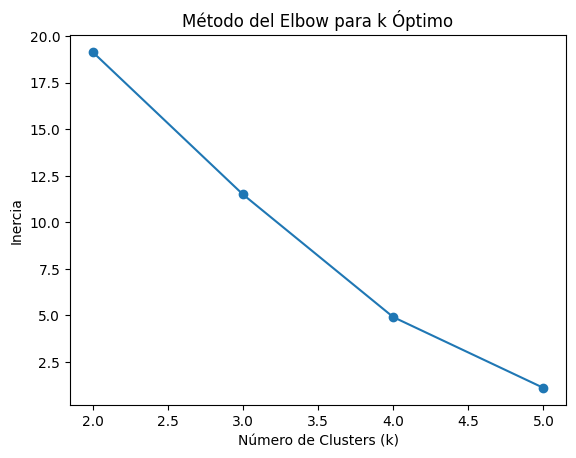

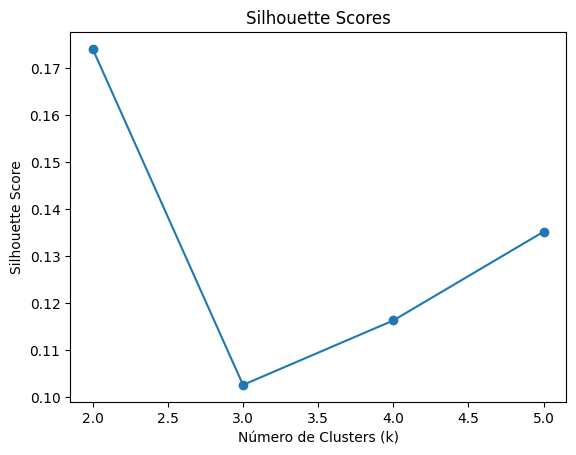

In [65]:
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []

for k in k_values:
    km2 = KMeans(n_clusters=k, random_state=42)
    labels = km2.fit_predict(X_scaled2)
    
    inertia.append(km2.inertia_)
    sil_scores.append(silhouette_score(X_scaled2, labels))

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Elbow para k Óptimo")
plt.show()

plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show();

In [66]:
km3_2 = KMeans(n_clusters=3, random_state=42).fit(X_scaled2)
km4_2 = KMeans(n_clusters=4, random_state=42).fit(X_scaled2)

labels3 = km3_2.labels_
labels4 = km4_2.labels_

print("k=3 sizes:", np.bincount(labels3))
print("k=4 sizes:", np.bincount(labels4))

k=3 sizes: [4 1 1]
k=4 sizes: [3 1 1 1]


In [ ]:
# Debido al número tan bajo de muestreo, los resultados de la clusterización son limitados.
# Nos muestran clsuters de 1 punto, lo que no es muy útil para sacar conclusiones sobre las recetas de bebidas energéticas.
# Por lo que sería mejor comparar directamente los datos sin clusterizar, o probar con otro dataset con más muestras para poder sacar conclusiones más sólidas sobre las recetas de bebidas energéticas.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.